In [1]:
import scipy
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
all_df = pd.read_csv('GSE124821_data_1e8.csv')


Number of replicates 6
Dendritic_quanTIseq    0.002621
NK_quanTIseq           0.000863
T.CD8_quanTIseq        0.000039
Tregs_quanTIseq        0.000341
dtype: float64
<class 'pandas.Series'>
0.0038637831629999998

Number of replicates 10
Dendritic_quanTIseq    0.003434
NK_quanTIseq           0.001140
T.CD8_quanTIseq        0.000922
Tregs_quanTIseq        0.000652
dtype: float64
<class 'pandas.Series'>
0.006148045144

Number of replicates 9
Dendritic_quanTIseq    0.002638
NK_quanTIseq           0.001086
T.CD8_quanTIseq        0.000035
Tregs_quanTIseq        0.000401
dtype: float64
<class 'pandas.Series'>
0.004160221992666666

Number of replicates 19
Dendritic_quanTIseq    0.002335
NK_quanTIseq           0.000806
T.CD8_quanTIseq        0.000028
Tregs_quanTIseq        0.000360
dtype: float64
total:0.0035284336252631573

Number of replicates 8
Dendritic_quanTIseq    0.003118
NK_quanTIseq           0.001121
T.CD8_quanTIseq        0.000053
Tregs_quanTIseq        0.000452
dtype: float64
total

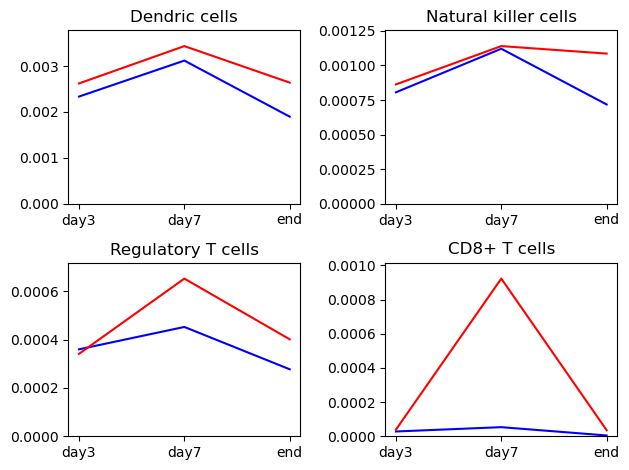

In [6]:
no_treatment_df = all_df[all_df['Mouse_treatment']!="no_treatment"]

quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]

UV_Ds = []
UV_NKs = []
UV_T8s = []
UV_Tregs = []
UV_time_points = ["UV_day3","UV_day7","UV_end"]

for day in UV_time_points:
    day_df = no_treatment_df[no_treatment_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    UV_Ds.append(averages["Dendritic_quanTIseq"])
    UV_NKs.append(averages["NK_quanTIseq"])
    UV_T8s.append(averages["T.CD8_quanTIseq"])
    UV_Tregs.append(averages["Tregs_quanTIseq"])
    UV_total = sum(averages)
    print(UV_total)
time_points = ["day3","day7","end"]

Ds = []
NKs = []
T8s = []
Tregs = []
scatter_Ds = []
scatter_NKs = []
scatter_Tregs = []
scatter_T8s = []
scatter_times = []

end_vecs = []
for day in time_points:
    day_df = no_treatment_df[no_treatment_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    quanTIseq_df = day_df.filter(items=quanTIseq_cols)
    averages = quanTIseq_df.mean()
    
    print(averages)
    stds = quanTIseq_df.std()
    
    # print(averages+stds)
    # print(averages-stds)
    # print(type(day_df.filter(items=quanTIseq_cols).mean()))
    Ds.append(averages["Dendritic_quanTIseq"])
    NKs.append(averages["NK_quanTIseq"])
    T8s.append(averages["T.CD8_quanTIseq"])
    Tregs.append(averages["Tregs_quanTIseq"])
    total = sum(averages)
    print(f"total:{total}")
    if "end" in day:
        end_data = quanTIseq_df.copy()
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_Ds.append(i)
                scatter_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_T8s.append(i)
    
        
        
fig,ax = plt.subplots(2,2)

Dplot = ax[0,0]
Dplot.plot(time_points,Ds,'b')
Dplot.plot(time_points,UV_Ds,'r')
Dplot.set_title('Dendric cells')
Dplot.set_ylim(0.0,max([*Ds,*UV_Ds])*1.1)
NKplot = ax[0,1]
NKplot.plot(time_points,NKs,'b')
NKplot.plot(time_points,UV_NKs,'r')
NKplot.set_title('Natural killer cells')

NKplot.set_ylim(0.0,max([*NKs,*UV_NKs])*1.1)

Tregplot = ax[1,0]
Tregplot.plot(time_points,Tregs,'b')
Tregplot.plot(time_points,UV_Tregs,'r')
Tregplot.set_title('Regulatory T cells')
Tregplot.set_ylim(0.0,max([*Tregs,*UV_Tregs])*1.1)

T8plot = ax[1,1]
T8plot.plot(time_points,T8s,'b')
T8plot.plot(time_points,UV_T8s,'r')
T8plot.set_title('CD8+ T cells')
T8plot.set_ylim(0.0,max([*T8s,*UV_T8s])*1.1)

plt.tight_layout()
plt.show()

In [7]:
# pandas dataframe of end data
end_data

,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq
24,0.003358,0.000808,0.000000,0.000400
25,0.001520,0.000312,0.000000,0.000176
26,0.003016,0.000766,0.000000,0.000339
83,0.001131,0.000413,0.000000,0.000212
84,0.000712,0.000351,0.000000,0.000198
85,0.000683,0.000341,0.000000,0.000189
103,0.000978,0.000469,0.000000,0.000182
104,0.001043,0.000550,0.000000,0.000115
105,0.001504,0.000538,0.000000,0.000153
106,0.001501,0.000415,0.000000,0.000141


In [49]:
#Now we solve the model
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC_comb,
               K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr_comb,d_T8,
              lambda_T8_comb,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC_comb*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr_comb*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8_comb*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))
def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    )    
params = {'lambda_C':1.5,
          'C_M':0.8,
          'eta_8':328.25,
          'eta_N':300,
          'd_C':0.17,
          'lambda_DC_comb':0.0012,
          # 'D_0':2e-5,
          'K_C':0.4,
          'd_D':0.1,
          'sigma_N':0.000325,
          'd_N':0.2,
          'gamma_N':150,
          'a_C':0.5,
          'beta_1':0.4,
          'beta_2':2e-4,
          'd_Tr':0.2,
          'lambda_Tr_comb':2e-4,
          'd_T8':0.25,
          'lambda_T8_comb':5e-5,
          'K_Tr':1e-9,
          'K_D':4e-4,
          'C_init':0.8,
          'D_init':0.0,
          'N_init':0.0,
          'Tr_init':0.0,
          'T8_init':0.0}

tspan = (0.0,14.0,)
C_init     = params['C_init']
D_init     = params['D_init']
N_init     = params['N_init']
Tr_init    = params['Tr_init']
T8_init    = params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]

In [54]:
sol = sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),abstol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))

[0.00000000e+00 6.01582878e-11 1.16151981e-10 1.64338402e-10
 2.05600260e-10 2.41128966e-10 2.71963240e-10 2.98989115e-10
 3.22939938e-10 3.44396365e-10 3.63786367e-10 3.81385225e-10
 3.97315533e-10 4.11559513e-10 4.24338819e-10 4.35871654e-10
 4.46270443e-10 4.55639299e-10 4.64074021e-10 4.71662093e-10
 4.78482687e-10 4.84606662e-10 4.90096561e-10 4.95006615e-10
 4.99382741e-10 5.03262543e-10 5.06681404e-10 5.09683956e-10
 5.12298925e-10 5.14552642e-10 5.16470224e-10 5.18075568e-10
 5.19391354e-10 5.20439044e-10 5.21238883e-10 5.21809896e-10
 5.22169891e-10 5.22335461e-10 5.22321978e-10 5.22143596e-10
 5.21813253e-10 5.21342669e-10 5.20742346e-10 5.20021566e-10
 5.19188512e-10 5.18254950e-10 5.17229643e-10 5.16118566e-10
 5.14927514e-10 5.13662102e-10 5.12327764e-10 5.10929757e-10
 5.09473154e-10 5.07962850e-10 5.06403561e-10 5.04799822e-10
 5.03155987e-10 5.01476232e-10 4.99764551e-10 4.98024760e-10
 4.96260494e-10 4.94475208e-10 4.92672177e-10 4.90854497e-10
 4.89025082e-10 4.871866

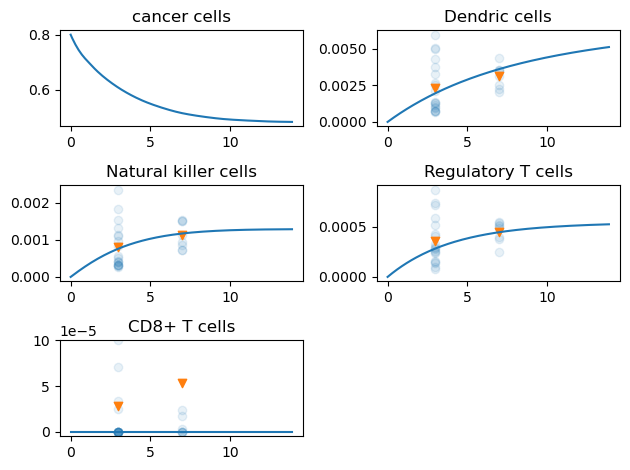

In [55]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
D_cells.scatter(scatter_times,scatter_Ds,alpha=0.1)
D_cells.scatter([3.0,7.0],Ds[:2],alpha=1.0,marker ='v')


NK_cells = ax[1,0]
NK_cells.plot(t,y[2])

NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_times,scatter_NKs,alpha=0.1)
NK_cells.scatter([3,7],NKs[:2],alpha=1.0,marker ='v')

Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_times,scatter_Tregs,alpha=0.1)
Treg.scatter([3,7],Tregs[:2],alpha=1.0,marker ='v')

T8 = ax[2,0]
T8.plot(t,y[4])
print(y[4])
T8.set_title('CD8+ T cells')
T8.scatter(scatter_times,scatter_T8s,alpha=0.1)
T8.scatter([3,7],T8s[:2],alpha=1.0,marker ='v')
T8.set_ylim(-0.000005,0.0001)
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()